# Creating a TPF and LCF

In this tutorial, we will learn the basics of `tess_asteroids` by creating a TPF and LCF for a couple of asteriods.

In [1]:
from tess_asteroids.utils import target_observability
from tess_asteroids import MovingTPF
import matplotlib.pyplot as plt
import numpy as np

## Main-belt asteroid 1980 VR1

Let's start with main-belt asteroid 1980 VR1.

### Was my target observed by TESS?

Firstly, we need to know if TESS observed this target and, if so, in what observing sector/camera/CCD. We can use the utils functions `target_observability` to find out. This might take a couple of minutes to run as it's checking all available TESS sectors.

In [2]:
target_observability("1980 VR1")

,sector,camera,ccd,dur,vmag
0,1,1,2,2.0,15.732333
1,1,1,1,20.0,15.706000
2,68,1,2,25.0,15.707769


Looks like our target was observed by TESS in sectors 1 (camera 1, CCD 1 & 2) and 68 (camera 1, CCD 2). Great, now we can create a TPF and LCF for that data!

### Creating a TPF

We can only create a TPF for one sector/camera/CCD at a time. Let's use sector 1, camera 1, CCD 1 as an example. 

Initialising `MovingTPF` with `from_name()` will query the JPL/Horizons database for the target's ephemeris during that sector. The `make_tpf()` function will then retrieve the relevant pixel data, perform a background correction and define the target aperture.

In [3]:
# Initialise MovingTPF for asteroid 1980 VR1 in TESS sector 1, camera 1, CCD 1
target = MovingTPF.from_name("1980 VR1", sector=1, camera=1, ccd=1)

# Make TPF (if we wanted to save this as a .fits file, we would set save=True)
target.make_tpf()

Warning from TESSSpacecraft(): {message : ErfaWarning('ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"'), category : 'ErfaWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/erfa/core.py', lineno : 133, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
The PRF model contained nans in the first frame (cadence number 273). The model was replaced with that from the following frame (cadence number 274).
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
The PRF model contained nans in

We can visualise the TPF by using the `animate_tpf()` function:

In [4]:
# Animate TPF (if we wanted to save this as a .gif file, we would set save=True)
target.animate_tpf()

### Understanding the contents of the TPF

The `make_tpf()` function creates an HDUList containing all of the TPF data. If we had set `save=True`, then this would have been written to a FITS file. 

The header of the "PRIMARY" HDU contains information about how the file was created, the observation and the target.

In [5]:
target.tpf_hdulist["PRIMARY"].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T / file contains extensions                       
SIMDATA =                    F / file is based on simulated data                
ORIGIN  = 'STScI/MAST'         / institution responsible for creating this file 
SPOCDATE= '2021-05-11'         / original SPOC FFI creation date                
SPOCVER = 'spoc-5.0.12-20200925' / SPOC version that processed FFI data         
DATE    = '2026-02-25'         / file creation date                             
EPHDATE = '2026-02-25'         / ephemeris date                                 
TSTART  =   1331.0161538382515 / observation start time in BTJD of first frame  
TSTOP   =   1352.3909265641566 / observation start time in BTJD of last frame   
DATE-OBS= '2018-07-31T12:22:

The "PIXELS" HDU contains a table with the same columns as a SPOC TPF, including:
- FLUX is the background corrected flux.
- QUALITY corresponds to the SPOC-assigned quality flags.
- POS_CORR1/POS_CORR2 are the column/row offset between the center of the TPF and the expected position of the target given the input ephemeris. 

In [6]:
target.tpf_hdulist["PIXELS"].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'CADENCENO'; format = 'I'
    name = 'FLUX'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11, 11)'
    name = 'FLUX_ERR'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11, 11)'
    name = 'FLUX_BKG'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11, 11)'
    name = 'FLUX_BKG_ERR'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11, 11)'
    name = 'QUALITY'; format = 'J'; disp = 'B16.16'
    name = 'POS_CORR1'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'POS_CORR2'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
)

The target aperture changes as a function of time. The "APERTURE" HDU contains the flattened aperture i.e. all pixels that are ever included in the time-dependent aperture. We can plot that as follows:

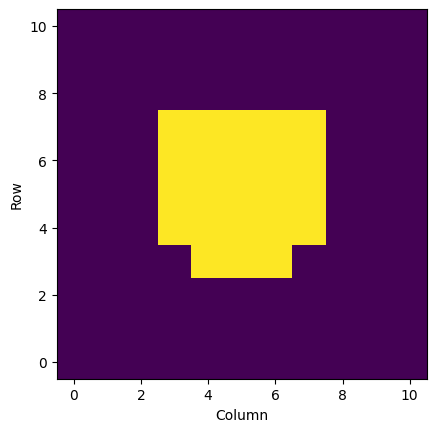

In [7]:
plt.imshow(target.tpf_hdulist["APERTURE"].data, origin="lower")
plt.xlabel("Column")
plt.ylabel("Row");

Finally, the "EXTRAS" HDU is a table containing columns not found in a SPOC TPF. For example:
- ORIGINAL_TIME is the original timestamp from the TESS FFI data. This timestamp is not accurate. TIME from the "PIXELS" HDU is more accurate and is the recommended value.
- CORNER1/CORNER2 are the original FFI column/row of the lower-left pixel in the TPF.
- PIXEL_QUALITY is defined by `tess_asteroids` to identify pixels that could have quality issues e.g. saturation.
- APERTURE is the aperture as a function of time.

In [8]:
target.tpf_hdulist["EXTRAS"].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'CADENCENO'; format = 'I'
    name = 'ORIGINAL_TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'ORIGINAL_TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'RA_PRED'; format = 'E'; unit = 'deg'; disp = 'E14.7'
    name = 'DEC_PRED'; format = 'E'; unit = 'deg'; disp = 'E14.7'
    name = 'CORNER1'; format = 'I'; unit = 'pixel'
    name = 'CORNER2'; format = 'I'; unit = 'pixel'
    name = 'PIXEL_QUALITY'; format = '121I'; disp = 'B16.16'; dim = '(11, 11)'
    name = 'APERTURE'; format = '121J'; dim = '(11, 11)'
)

### Creating a LCF

After we've made our TPF, we can extract the lightcurve using aperture and/or PSF photometry. By default, the `make_lc()` function creates lightcurves using both methods.

In [9]:
# Extract LC (if we wanted to save this as a .fits file, we would set save=True)
target.make_lc()

The PRF model contained nans in the first frame (cadence number 273). The model was replaced with that from the following frame (cadence number 274).
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 959/959 [00:00<00:00, 6204.35it/s]


We can then use the helper function `plot_lc()` to plot the lightcurves.

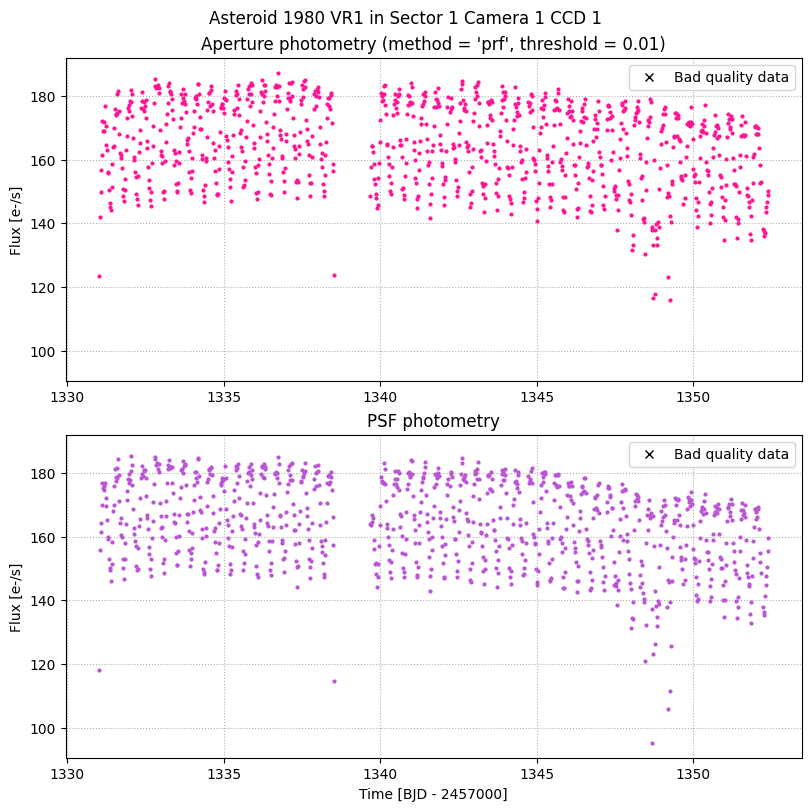

In [10]:
# Plot LC with default settings (if we wanted to save this as a .png file, we would set save=True)
target.plot_lc()

This is flagging bad quality data with a mask which combines the SPOC quality flags and the `tess_asteroids` lightcurve quality flags. By default it masks the following bits:

- For SPOC, it masks bits [1, 2, 3, 4, 5, 6, 8, 10, 13, 15] as recommended in the [TESS Archive Manual](https://outerspace.stsci.edu/spaces/TESS/pages/14563420/2.0+-+Data+Product+Overview).
- For `tess_asteroids`, it masks bits [2, 4, 10] as defined by `_create_lc_quality()`. This corresponds to cadences with at least one non-science pixel inside the mask, at least one saturated pixel inside the mask or a pixel with a negative raw flux (i.e. before background correction).

In the above example, there is no bad quality data when using the default mask. The bits to mask can be updated independently for SPOC, the aperture lightcurve and the PSF lightcurve:

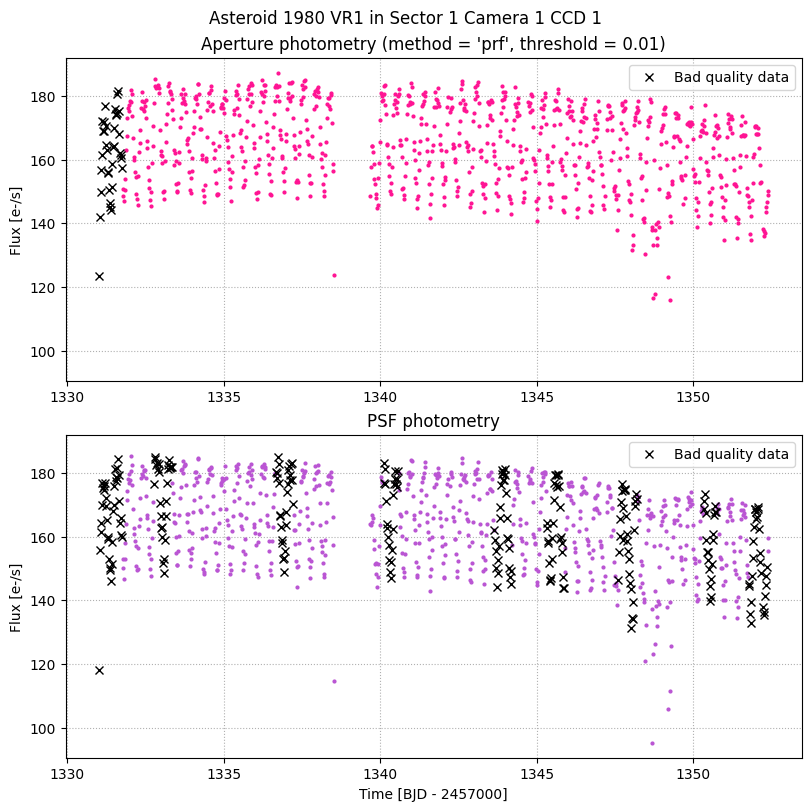

In [11]:
# Plot LC with custom bad quality masking
target.plot_lc(bad_spoc_bits="all", bad_ap_bits="none", bad_psf_bits=[3])

### Understanding the contents of the LCF

The `make_lc()` function creates an HDUList containing all of the LC data. If we had set `save=True`, then this would have been written to a FITS file.

The header of the "PRIMARY" HDU contains information about how the file was created and the target. It's very similar to the primary header from the TPF:

In [12]:
target.lc_hdulist["PRIMARY"].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T / file contains extensions                       
SIMDATA =                    F / file is based on simulated data                
ORIGIN  = 'STScI/MAST'         / institution responsible for creating this file 
SPOCDATE= '2021-05-11'         / original SPOC FFI creation date                
SPOCVER = 'spoc-5.0.12-20200925' / SPOC version that processed FFI data         
DATE    = '2026-02-25'         / file creation date                             
EPHDATE = '2026-02-25'         / ephemeris date                                 
TELAPSE =    21.37477272590513 / [d] TSTOP - TSTART                             
TSTART  =   1331.0161538382515 / observation start time in BTJD of first frame  
TSTOP   =   1352.39092656415

The "LIGHTCURVE_AP" HDU contains all of the aperture photometry data. For example:
- FLUX and FLUX_ERR are created from the TPF using aperture photometry. These values have been corrected to account for the predicted fraction of the target's flux outside of the aperture.
- MOM_CENTR1/2 are the measured flux-weighted centroids of the target.
- QUALITY is the original SPOC assigned quality flag.
- AP_QUALITY is defined by `tess_asteroids` to identify cadences that could have quality issues e.g. saturated pixels.
- NPIX is the number of pixels used to derive the photometry.

In [13]:
target.lc_hdulist["LIGHTCURVE_AP"].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'CADENCENO'; format = 'I'
    name = 'QUALITY'; format = 'J'; disp = 'B16.16'
    name = 'FLUX'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'FLUX_ERR'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'TESSMAG'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'TESSMAG_ERR'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'TESSMAG_UERR'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'TESSMAG_LERR'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'FLUX_BKG'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'FLUX_BKG_ERR'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'MOM_CENTR1'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'MOM_CENTR1_ERR'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'MOM_CENTR2'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'MOM_CENTR2_ERR'; format = 'E'; unit = 'pixel'; disp = 'E

The "LIGHTCURVE_PSF" HDU contains all of the PSF photometry data. For example:
- FLUX and FLUX_ERR are created from the TPF using PSF photometry.
- QUALITY is the original SPOC assigned quality flag.
- RED_CHI2 is the reduced chi-sqaured of the PRF model fit to the data.
- PSF_QUALITY is defined by `tess_asteroids` to identify cadences that could have quality issues e.g. PRF fitting failed.

In [14]:
target.lc_hdulist["LIGHTCURVE_PSF"].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'TIME_UERR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'TIME_LERR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'CADENCENO'; format = 'I'
    name = 'QUALITY'; format = 'J'; disp = 'B16.16'
    name = 'FLUX'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'FLUX_ERR'; format = 'E'; unit = 'e-/s'; disp = 'E14.7'
    name = 'TESSMAG'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'TESSMAG_ERR'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'TESSMAG_UERR'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'TESSMAG_LERR'; format = 'E'; unit = 'mag'; disp = 'E14.7'
    name = 'RED_CHI2'; format = 'E'; disp = 'E14.7'
    name = 'PSF_QUALITY'; format = 'I'; disp = 'B16.16'
    name = 'QUALITY_FRACTION'; format = 'E'; disp = 'E14.7'
    name = 'N_CADENCES'; format = 'I'
    name = 'BKG_STD'

The "EXTRAS" HDU contains extra information. For example:

- ORIGINAL_TIME and ORIGINAL_TIMECORR are the time and barycentric correction derived by SPOC.
- CORNER1/2 are the original FFI column/row of the lower-left pixel in the TPF.
- RA_PRED/DEC_PRED are the expected position of the target in world coordinates.
- SUN_DISTANCE/OBS_DISTANCE/STO_ANGLE are the distance from the Sun [AU], distance from the observer (TESS) [AU] and the Sun-Target-Observer angle [deg].

In [15]:
target.lc_hdulist["EXTRAS"].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'ORIGINAL_TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'ORIGINAL_TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'CADENCENO'; format = 'I'
    name = 'CORNER1'; format = 'I'; unit = 'pixel'
    name = 'CORNER2'; format = 'I'; unit = 'pixel'
    name = 'EPHEM1'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'EPHEM2'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'RA_PRED'; format = 'E'; unit = 'deg'; disp = 'E14.7'
    name = 'DEC_PRED'; format = 'E'; unit = 'deg'; disp = 'E14.7'
    name = 'SUN_DISTANCE'; format = 'E'; unit = 'AU'; disp = 'E14.7'
    name = 'OBS_DISTANCE'; format = 'E'; unit = 'AU'; disp = 'E14.7'
    name = 'STO_ANGLE'; format = 'E'; unit = 'deg'; disp = 'E14.7'
)

## Near-Earth asteroid 2013 OS3

Let's now have a look at near-Earth asteroid 2013 OS3:

In [16]:
target_observability("2013 OS3")

,sector,camera,ccd,dur,vmag
0,20,2,1,9.0,17.72440
1,20,2,2,1.0,16.97850
2,20,2,3,6.0,16.36100
3,20,1,2,3.0,15.51225
4,20,1,3,0.0,15.14800
5,93,2,3,4.0,19.87080
6,93,1,2,4.0,19.88320


This asteroid passed through five camera/CCD combinations during sector 20! That's because it moves much faster across the TESS detectors due to its proximity to Earth (and hence TESS). Notice that sector 20, camera 1, CCD 3 has duration of 0.0 days - this just means it was observed for less than a day on this CCD.

In [17]:
# Initialise MovingTPF for asteroid 2013 OS3 in TESS sector 20, camera 2, CCD 3
target = MovingTPF.from_name("2013 OS3", sector=20, camera=2, ccd=3)

# Make TPF
target.make_tpf()

# Animate TPF
target.animate_tpf()

Some of the requested pixels are outside of the FFI science array (1<=row<=2048, 45<=col<=2092), but they will be set to NaN in your TPF.
Warning from TESSSpacecraft(): {message : ErfaWarning('ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"'), category : 'ErfaWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/erfa/core.py', lineno : 133, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Row(s) > 2048)'), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 62, line : None}
The PRF model contained nans in the first frame

Notice that this asteroid has a more elongated shape. Due to the speed with which it moves across the TESS detector, the flux gets smeared along the trail during the long exposures. In a few of the frames, the asteroid reaches the edge of the TPF, so we are probably losing some of the target's flux. That can be easily fixed by creating a larger TPF to ensure we capture all of the flux! (Note: The first cadence of this TPF is filled with NaN values because these are non-science pixels.)

In [18]:
# Make TPF - larger shape
target.make_tpf(shape=(15,15))

# Animate TPF
target.animate_tpf()

Some of the requested pixels are outside of the FFI science array (1<=row<=2048, 45<=col<=2092), but they will be set to NaN in your TPF.
Warning from TESSSpacecraft(): {message : ErfaWarning('ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"'), category : 'ErfaWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/erfa/core.py', lineno : 133, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Row(s) > 2048)'), category : 'LKPRFWarning', filename : '/Users/atuson/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 62, line : None}
The PRF model contained nans in the first frame

That looks better, the target is more comfortably within the bounds of the TPF now.

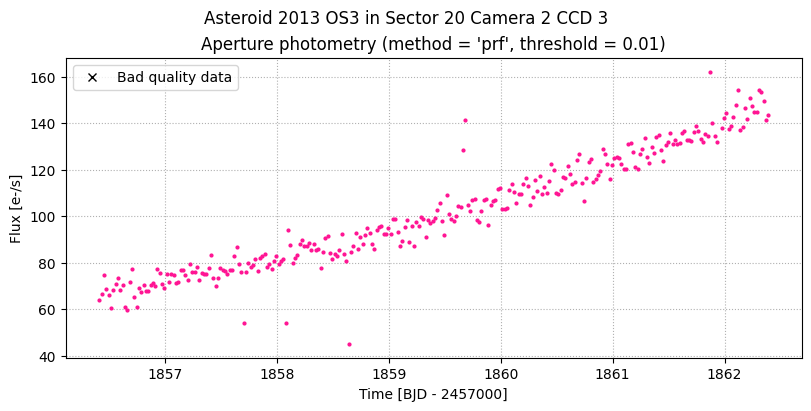

In [19]:
# Make aperture LC only
target.make_lc(method="aperture")

# Plot LC
target.plot_lc()